# report of energy comparing for ml and ref Nanoscale, 2017, 9, 7143 SI
and save all 5a, 5b to energies_ml.csv

In [1]:
import pandas as pd
from pathlib import Path
from lzn.universal import *

# from pandas.conftest import axis


In [2]:
def sort_by_number(df, column="id"):
    tmp = df[column].str.extract(r"^(\d+)([A-Za-z])", expand=True)  # number, letter
    df_sorted = (
        df.assign(_n=tmp[0].astype(int), _s=tmp[1].str.lower())
          .sort_values(["_n", "_s"])
          .drop(columns=["_n", "_s"])
          .reset_index(drop=True)
    )
    return df_sorted

### reference energies

In [3]:
energies_path = to_path("~/TiO2/tio2_ChenDixon_xyz/energies.csv")
df_ref = pd.read_csv(energies_path)
df_ref = df_ref[["id", "energy_eV"]]

In [4]:
ref_e5 = df_ref["energy_eV"][0]
ref_e8 = df_ref["energy_eV"][2]
ref_e40 = df_ref["energy_eV"][4]
ref_e64 = df_ref["energy_eV"][7]


# df_ref.loc[0:1, "energy_eV"] -= ref_e5
# df_ref.loc[2:3, "energy_eV"] -= ref_e8
# df_ref.loc[4:6, "energy_eV"] -= ref_e40
# df_ref.loc[7:8, "energy_eV"] -= ref_e64


In [5]:
df_ref = sort_by_number(df_ref)
df_ref

,id,energy_eV
0,1a,-2.720840e+04
1,5a,-1.360622e+05
2,5b,-1.360621e+05
3,8a,-2.177042e+05
4,8b,-2.177041e+05
5,12a,-3.265599e+05
6,12b,-3.265588e+05
7,12c,-3.265584e+05
8,12d,-3.265562e+05
9,40a,-1.088552e+06


### ml energies

In [6]:
mlE_dir = to_path("~/TiO2/tio2_ChenDixon_out")
modals = [x for x in mlE_dir.iterdir() if x.is_dir()]
mlE_path = [x / "energies.csv" for x in modals]

print(modals)
print(mlE_path)

df_ml = [pd.read_csv(x) for x in mlE_path]

# file values like: "40a.xyz", "5b.xyz", "64b.xyz"
df_ml_sorted = []
for df in df_ml:
    tmp = df["file"].str.extract(r"^(\d+)([A-Za-z])", expand=True)  # number, letter
    df_sorted = (
        df.assign(_n=tmp[0].astype(int), _s=tmp[1].str.lower())
          .sort_values(["_n", "_s"])
          .drop(columns=["_n", "_s"])
          .reset_index(drop=True)
    )
    df_ml_sorted.append(df_sorted)


[PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/matpes_pbe'), PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/omat24'), PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/omol25_low'), PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/mpa'), PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/matpes_r2scan')]
[PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/matpes_pbe/energies.csv'), PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/omat24/energies.csv'), PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/omol25_low/energies.csv'), PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/mpa/energies.csv'), PosixPath('/home/zining/TiO2/tio2_ChenDixon_out/matpes_r2scan/energies.csv')]


In [7]:
df_ml_sorted[1]

,file,E_initial,E_final,dE
0,1a.xyz,-21.110718,-21.118988,-0.008270
1,5a.xyz,-125.148438,-125.188133,-0.039696
2,5b.xyz,-125.172073,-125.203354,-0.031281
3,8a.xyz,-204.589981,-204.643555,-0.053574
4,8b.xyz,-204.489136,-204.538528,-0.049393
5,12a,-310.363190,-310.435455,-0.072266
6,12b,-309.784943,-309.988068,-0.203125
7,12c,-309.379181,-309.457001,-0.077820
8,12d,-306.548767,-306.616760,-0.067993
9,40a.xyz,-1051.221436,-1051.361938,-0.140503


###### Save 5ab ml energies to energies_ml.csv

In [8]:
# save_path = to_path("~/TiO2/energies_ml.csv")
# df_save = pd.read_csv(save_path)
#
# for i, modal_i_path in enumerate(mlE_path):
#     modal_i = modal_i_path.parent.stem
#     df_ml_i = df_ml_sorted[i]
#     ini_5a, ini_5b = df_ml_i.loc[0, 'E_initial'], df_ml_i.loc[1, 'E_initial']
#     fin_5a, fin_5b = df_ml_i.loc[0, 'E_final'], df_ml_i.loc[1, 'E_final']
#     df_save.loc[2*i] = [modal_i, int(0), ini_5a, ini_5b]
#     df_save.loc[2*i+1] = [modal_i, int(1), fin_5a, fin_5b]
#
# df_save
# df_save.to_csv(save_path, index=False)


###### Final energies by ml ff

In [9]:
for x in df_ml_sorted:
    ref_e5 = x.loc[0, "E_initial"]
    ref_e8 = x.loc[2, "E_initial"]
    ref_e40 = x.loc[4, "E_initial"]
    ref_e64 = x.loc[7, "E_initial"]

    print(ref_e5)

    # x.loc[0:1, "E_initial"] -= ref_e5
    # x.loc[2:3, "E_initial"] -= ref_e8
    # x.loc[4:6, "E_initial"] -= ref_e40
    # x.loc[7:8, "E_initial"] -= ref_e64

-21.111146926879883
-21.1107177734375
-27209.03515625
-21.11500358581543
-28.17835235595703


In [10]:
df_ml_norm = [x["E_final"] for x in df_ml_sorted]
df_ml_norm[1]

0      -21.118988
1     -125.188133
2     -125.203354
3     -204.643555
4     -204.538528
5     -310.435455
6     -309.988068
7     -309.457001
8     -306.616760
9    -1051.361938
10   -1051.371704
11   -1047.752563
12   -1683.945679
13   -1685.348633
Name: E_final, dtype: float64

In [11]:
col_names = [str(x.name) for x in modals]
print(col_names)
df_all = pd.concat(df_ml_norm, axis=1)
df_all.columns = col_names
df_all

['matpes_pbe', 'omat24', 'omol25_low', 'mpa', 'matpes_r2scan']


,matpes_pbe,omat24,omol25_low,mpa,matpes_r2scan
0,-21.123470,-21.118988,-2.720908e+04,-21.125584,-28.186312
1,-125.164551,-125.188133,-1.360669e+05,-125.493195,-162.538055
2,-125.135315,-125.203354,-1.360671e+05,-125.462975,-162.602905
3,-204.586060,-204.643555,-2.177124e+05,-205.026489,-265.099854
4,-204.451141,-204.538528,-2.177124e+05,-204.944855,-264.993500
5,-310.358765,-310.435455,-3.265729e+05,-310.954590,-401.687134
6,-309.802795,-309.988068,-3.265731e+05,-310.807037,-401.559967
7,-309.391724,-309.457001,-3.265724e+05,-310.273224,-401.003021
8,-306.588745,-306.616760,-3.265678e+05,-307.092346,-396.958008
9,-1051.298828,-1051.361938,-1.088597e+06,-1053.583252,-1359.592163


In [12]:
df_allx = pd.concat([df_ref, df_all], axis=1)
df_allx = df_allx.rename(columns={"energy_eV": "ref_eV"})

In [13]:
# df_allx.set_index("id", inplace=True)
path_allx = to_path("~/organized/901_data/chen_1-64_5mlip_a.csv")
df_allx.to_csv(path_allx, index=False)
df_allx

,id,ref_eV,matpes_pbe,omat24,omol25_low,mpa,matpes_r2scan
0,1a,-2.720840e+04,-21.123470,-21.118988,-2.720908e+04,-21.125584,-28.186312
1,5a,-1.360622e+05,-125.164551,-125.188133,-1.360669e+05,-125.493195,-162.538055
2,5b,-1.360621e+05,-125.135315,-125.203354,-1.360671e+05,-125.462975,-162.602905
3,8a,-2.177042e+05,-204.586060,-204.643555,-2.177124e+05,-205.026489,-265.099854
4,8b,-2.177041e+05,-204.451141,-204.538528,-2.177124e+05,-204.944855,-264.993500
5,12a,-3.265599e+05,-310.358765,-310.435455,-3.265729e+05,-310.954590,-401.687134
6,12b,-3.265588e+05,-309.802795,-309.988068,-3.265731e+05,-310.807037,-401.559967
7,12c,-3.265584e+05,-309.391724,-309.457001,-3.265724e+05,-310.273224,-401.003021
8,12d,-3.265562e+05,-306.588745,-306.616760,-3.265678e+05,-307.092346,-396.958008
9,40a,-1.088552e+06,-1051.298828,-1051.361938,-1.088597e+06,-1053.583252,-1359.592163


In [14]:
df_allr = df_allx.copy()
ref_1a = df_allr.iloc[0, 1:]

def get_relative_energies(df, n_divide, n_start, n_end):
    for i in range(n_start, n_end):
        df.iloc[i, 1:] = df.iloc[i, 1:] / n_divide - ref_1a
    return df

get_relative_energies(df_allr, 1, 0, 1)
get_relative_energies(df_allr, 5, 1, 3)
get_relative_energies(df_allr, 8, 3, 5)
get_relative_energies(df_allr, 12, 5, 9)
get_relative_energies(df_allr, 40, 9, 12)
get_relative_energies(df_allr, 64, 12, 14)


,id,ref_eV,matpes_pbe,omat24,omol25_low,mpa,matpes_r2scan
0,1a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,5a,-4.026534,-3.909440,-3.918639,-4.299219,-3.973055,-4.321299
2,5b,-4.024956,-3.903593,-3.921683,-4.336719,-3.967011,-4.334269
3,8a,-4.621538,-4.449787,-4.461456,-4.964844,-4.502728,-4.951170
4,8b,-4.607548,-4.432922,-4.448328,-4.972656,-4.492523,-4.937876
5,12a,-4.924655,-4.739760,-4.750633,-5.324219,-4.787299,-5.287616
6,12b,-4.831207,-4.693429,-4.713351,-5.342448,-4.775003,-5.277019
7,12c,-4.796835,-4.659173,-4.669095,-5.287760,-4.730518,-5.230607
8,12d,-4.616196,-4.425592,-4.432409,-4.902344,-4.465445,-4.893522
9,40a,-5.394503,-5.159000,-5.165060,-5.849219,-5.213998,-5.803492


In [15]:
path_allr = to_path("~/organized/901_data/chen_1-64_5mlip_r.csv")
df_allr.to_csv(path_allr, index=False)
df_allr

,id,ref_eV,matpes_pbe,omat24,omol25_low,mpa,matpes_r2scan
0,1a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,5a,-4.026534,-3.909440,-3.918639,-4.299219,-3.973055,-4.321299
2,5b,-4.024956,-3.903593,-3.921683,-4.336719,-3.967011,-4.334269
3,8a,-4.621538,-4.449787,-4.461456,-4.964844,-4.502728,-4.951170
4,8b,-4.607548,-4.432922,-4.448328,-4.972656,-4.492523,-4.937876
5,12a,-4.924655,-4.739760,-4.750633,-5.324219,-4.787299,-5.287616
6,12b,-4.831207,-4.693429,-4.713351,-5.342448,-4.775003,-5.277019
7,12c,-4.796835,-4.659173,-4.669095,-5.287760,-4.730518,-5.230607
8,12d,-4.616196,-4.425592,-4.432409,-4.902344,-4.465445,-4.893522
9,40a,-5.394503,-5.159000,-5.165060,-5.849219,-5.213998,-5.803492


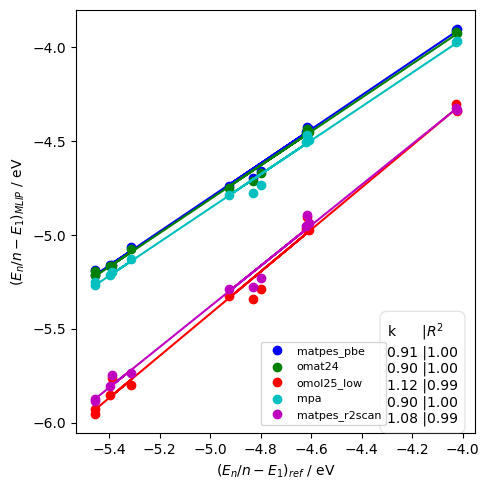

In [23]:
import matplotlib.pyplot as plt
from plot_with_regression import plot_with_regression

df_ = df_allr.iloc[1:, :]

fig1 = plt.figure(1, figsize = (5,5))
gs = fig1.add_gridspec(1,1)

grid_n = fig1.add_subplot(gs[0, 0])

slope_l, se_l = [], []
for j, col_ in enumerate(["matpes_pbe", "omat24", "omol25_low", "mpa", "matpes_r2scan"]):
    grid_n, slope, se = plot_with_regression(grid_n, j, df_["ref_eV"], df_[col_], col_)
    slope_l.append(slope)
    se_l.append(se)

lreg_text = "\n".join([r"k      |$R^2$"] + [f"{slope_l[i_]:.2f} |{se_l[i_]:.2f}" for i_ in range(5)])

grid_n.set_ylabel(r"$(E_n/n-E_{1})_{MLIP}$ / eV")
grid_n.set_xlabel(r"$(E_n/n-E_{1})_{ref}$ / eV")
grid_n.legend(fontsize=8, bbox_to_anchor=(0.45, 0.23))  # outside right
grid_n.text(
    -4.3, -6. ,
    lreg_text,
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.2, edgecolor='gray')
    )

fig1.tight_layout()

path_ = to_path("~/organized/901_data/chen_1-64_5mlip_r.pdf")
fig1.savefig(path_)

plt.show()


In [ ]:


# num = 9 # plot first num structures
# labels = [5, 8, 40, 64]
#
# plt.clf()
# x = range(num)
# ycols = df_allx.columns[2:]             # number of columns (modals)
#
# fig, ax = plt.subplots()
#
# for col in ycols:
#     plt.plot(x, df_allx[col][:num].to_numpy(), 'o', label=col)
# plt.plot(x, df_allx["ref_eV"][:num].to_numpy(), 'rx', label="ref_eV", alpha=1)
#
# plt.xlabel("Index")
# plt.ylabel("E/ eV")
# plt.grid(True, linestyle='--', alpha=0.3)
#
# xs = [0, 2, 4, 7]
# ax.set_xticks(xs)                              # put ticks at these x values
# ax.grid(True, axis="x", which="major", linestyle="-", alpha=0.5)  # solid vertical grid lines
# ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))  # outside right
# ax.set_xticklabels(labels)
#
# fig.tight_layout()
# plt.show()


###### final ml energy after ml opt
5a and 5b

In [ ]:
df_ml_final_norm = []
for x in df_ml_sorted:
    ref_e5 = x["E_final"][0]
    df_ml_final_norm.append(x.loc[0:1, "E_final"] - ref_e5)

print(df_ml_final_norm)
df_ml_final_norm[1]

In [ ]:
col_names = [str(x.name) for x in modals]
print(col_names)
df_final_all = pd.concat(df_ml_final_norm, axis=1)
df_final_all.columns = col_names

df_final_allx = pd.concat([df_ref[0:2], df_final_all], axis=1)
df_final_allx = df_final_allx.rename(columns={"energy_eV": "ref_eV"})
df_final_allx

### dE optimization

In [ ]:
l_dE = []
for x in df_ml_sorted:
    l_dE.append(x["dE"])

df_dE = pd.concat(l_dE, axis=1)
df_dE.columns = col_names
df_dE = pd.concat([df_ref, df_dE], axis=1)

df_dE

In [ ]:
df_5 = df_dE.loc[0:1, :]
df_5

In [ ]:
df_5.loc[2, "id"] = "dE"
df_5.iloc[2, 1:] = df_5.iloc[1, 1:] - df_5.iloc[0, 1:]
df_5